# Baseline 224 cancer-associated stroma misclassification confidence

This notebook investigates recall-side errors for the `baseline_224` small CNN. It uses the saved test-set probabilities from `results/baseline_224/test_predictions.npz`, so the model does not need to be run again.

The question is: when the true class is cancer-associated stroma, how confident is the model when it predicts the correct class compared with the dominant false-negative classes?

Classes inspected here:

- true class: cancer-associated stroma
- inspected predictions: debris, smooth muscle, cancer-associated stroma, colorectal adenocarcinoma epithelium


In [5]:
from pathlib import Path
import os

import numpy as np
import pandas as pd

MPLCONFIGDIR = Path("/tmp/pathmnist-matplotlib-cache")
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "results" / "baseline_224" / "test_predictions.npz").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULT_DIR = PROJECT_ROOT / "results" / "baseline_224"
PREDICTION_FILE = RESULT_DIR / "test_predictions.npz"
FIGURE_FILE = RESULT_DIR / "stroma_misclassification_confidence_distributions.svg"
COMPARISON_FIGURE_FILE = RESULT_DIR / "stroma_vs_nonstroma_predicted_class_confidence.svg"

CLASS_NAMES = [
    "adipose",
    "background",
    "debris",
    "lymphocytes",
    "mucus",
    "smooth muscle",
    "normal colon mucosa",
    "cancer-associated stroma",
    "colorectal adenocarcinoma epithelium",
]

STROMA_CLASS = 7
TARGET_CLASSES = {
    2: "debris",
    5: "smooth muscle",
    7: "cancer-associated stroma",
    8: "colorectal adenocarcinoma epithelium",
}
TARGET_WRONG_CLASSES = {class_id: label for class_id, label in TARGET_CLASSES.items() if class_id != STROMA_CLASS}

data = np.load(PREDICTION_FILE)
y_true = data["y_true"].reshape(-1).astype(int)
y_prob = data["y_prob"]
y_pred = y_prob.argmax(axis=1)
pred_confidence = y_prob[np.arange(len(y_prob)), y_pred]

print(f"Loaded {len(y_true):,} test predictions from {PREDICTION_FILE}")
print(f"Probability array shape: {y_prob.shape}")


Loaded 7,180 test predictions from /Users/nick/Workspace/pathmnist-classification-improvement/results/baseline_224/test_predictions.npz
Probability array shape: (7180, 9)


In [6]:
stroma_mask = y_true == STROMA_CLASS
stroma_indices = np.flatnonzero(stroma_mask)

stroma_df = pd.DataFrame(
    {
        "sample_index": stroma_indices,
        "true_class": [CLASS_NAMES[STROMA_CLASS]] * len(stroma_indices),
        "pred_class": y_pred[stroma_mask],
        "pred_label": [CLASS_NAMES[i] for i in y_pred[stroma_mask]],
        "pred_confidence": pred_confidence[stroma_mask],
        "stroma_probability": y_prob[stroma_mask, STROMA_CLASS],
        "debris_probability": y_prob[stroma_mask, 2],
        "smooth_muscle_probability": y_prob[stroma_mask, 5],
        "cancer_epithelium_probability": y_prob[stroma_mask, 8],
    }
)
stroma_df["is_correct"] = stroma_df["pred_class"] == STROMA_CLASS

target_errors = stroma_df[stroma_df["pred_class"].isin(TARGET_WRONG_CLASSES)].copy()

print(f"True cancer-associated stroma samples: {len(stroma_df):,}")
print(f"Correctly classified as stroma: {int(stroma_df['is_correct'].sum()):,}")
print(f"Misclassified into target classes: {len(target_errors):,}")

stroma_df["pred_label"].value_counts().rename_axis("predicted class").to_frame("count")


True cancer-associated stroma samples: 421
Correctly classified as stroma: 219
Misclassified into target classes: 191


,count
predicted class,
cancer-associated stroma,219
smooth muscle,78
colorectal adenocarcinoma epithelium,77
debris,36
lymphocytes,7
mucus,2
normal colon mucosa,2


## Confidence summary

`pred_confidence` is the softmax probability assigned to the class selected by `argmax`. For the rows below, this is the confidence assigned to the wrong predicted class.

In [7]:
summary = (
    stroma_df[stroma_df["pred_class"].isin(TARGET_CLASSES)]
    .groupby("pred_label")["pred_confidence"]
    .agg(count="count", mean="mean", median="median", min="min", max="max")
    .reindex(TARGET_CLASSES.values())
)

summary.style.format(
    {
        "mean": "{:.3f}",
        "median": "{:.3f}",
        "min": "{:.3f}",
        "max": "{:.3f}",
    }
)


,count,mean,median,min,max
pred_label,,,,,
debris,36,0.667,0.707,0.342,0.883
smooth muscle,78,0.574,0.554,0.283,0.945
cancer-associated stroma,219,0.762,0.844,0.283,0.994
colorectal adenocarcinoma epithelium,77,0.577,0.578,0.280,0.962


## Confidence distributions for true stroma predictions

Each bar chart contains only samples whose true label is cancer-associated stroma. The first, second, and fourth panels show false negatives; the cancer-associated stroma panel shows correctly classified stroma samples. All panels use the confidence assigned to the predicted class.


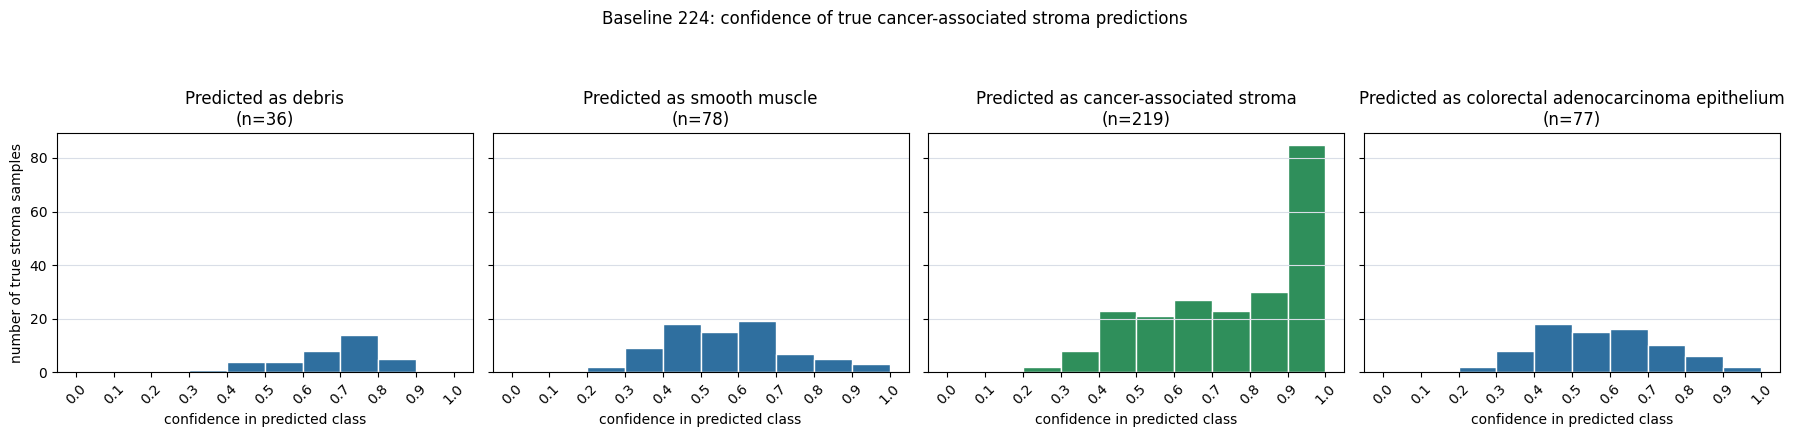

Saved figure to /Users/nick/Workspace/pathmnist-classification-improvement/results/baseline_224/stroma_misclassification_confidence_distributions.svg


In [8]:
bins = np.linspace(0.0, 1.0, 11)
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)

for ax, (class_id, label) in zip(axes, TARGET_CLASSES.items()):
    panel_df = stroma_df[stroma_df["pred_class"] == class_id]
    values = panel_df["pred_confidence"]
    color = "#2f6f9f" if class_id != STROMA_CLASS else "#2f8f5b"
    ax.hist(values, bins=bins, color=color, edgecolor="white", linewidth=1.0)
    ax.set_title(f"Predicted as {label}\n(n={len(values)})")
    ax.set_xlabel("confidence in predicted class")
    ax.set_xticks(bins)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", color="#d9dee7", linewidth=0.8)

axes[0].set_ylabel("number of true stroma samples")
fig.suptitle("Baseline 224: confidence of true cancer-associated stroma predictions", y=1.08)
fig.tight_layout()
FIGURE_FILE.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_FILE, bbox_inches="tight")
plt.show()

print(f"Saved figure to {FIGURE_FILE}")


## Stroma false negatives versus non-stroma predictions

The next graphic compares confidence in the same predicted class. Blue bars show true cancer-associated stroma samples that were assigned to the target class. Red bars show all other test samples assigned to that same class, excluding samples whose true label is cancer-associated stroma.

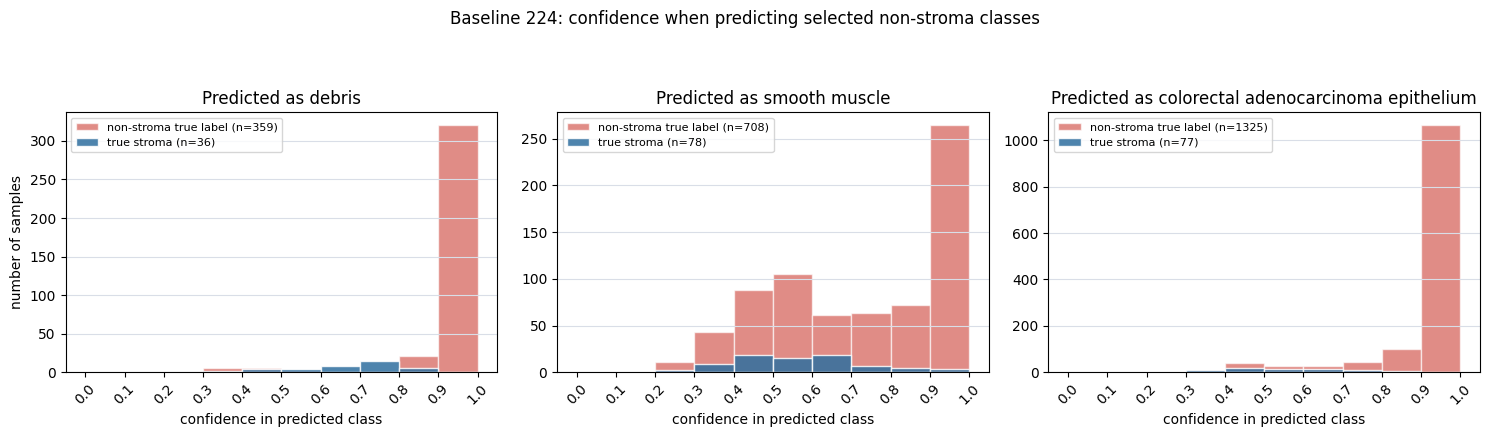

Saved figure to /Users/nick/Workspace/pathmnist-classification-improvement/results/baseline_224/stroma_vs_nonstroma_predicted_class_confidence.svg


,predicted_class,true_stroma_count,true_stroma_mean_confidence,nonstroma_count,nonstroma_mean_confidence
0,debris,36,0.667,359,0.952
1,smooth muscle,78,0.574,708,0.736
2,colorectal adenocarcinoma epithelium,77,0.577,1325,0.921


In [9]:
comparison_classes = {
    2: "debris",
    5: "smooth muscle",
    8: "colorectal adenocarcinoma epithelium",
}

bins = np.linspace(0.0, 1.0, 11)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=False)

comparison_summary = []
for ax, (class_id, label) in zip(axes, comparison_classes.items()):
    stroma_values = pred_confidence[(y_true == STROMA_CLASS) & (y_pred == class_id)]
    nonstroma_values = pred_confidence[(y_true != STROMA_CLASS) & (y_pred == class_id)]

    ax.hist(
        nonstroma_values,
        bins=bins,
        color="#d04f45",
        alpha=0.65,
        edgecolor="white",
        linewidth=1.0,
        label=f"non-stroma true label (n={len(nonstroma_values)})",
    )
    ax.hist(
        stroma_values,
        bins=bins,
        color="#2f6f9f",
        alpha=0.85,
        edgecolor="white",
        linewidth=1.0,
        label=f"true stroma (n={len(stroma_values)})",
    )
    ax.set_title(f"Predicted as {label}")
    ax.set_xlabel("confidence in predicted class")
    ax.set_xticks(bins)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", color="#d9dee7", linewidth=0.8)
    ax.legend(fontsize=8)

    comparison_summary.append(
        {
            "predicted_class": label,
            "true_stroma_count": len(stroma_values),
            "true_stroma_mean_confidence": float(np.mean(stroma_values)) if len(stroma_values) else np.nan,
            "nonstroma_count": len(nonstroma_values),
            "nonstroma_mean_confidence": float(np.mean(nonstroma_values)) if len(nonstroma_values) else np.nan,
        }
    )

axes[0].set_ylabel("number of samples")
fig.suptitle("Baseline 224: confidence when predicting selected non-stroma classes", y=1.08)
fig.tight_layout()
fig.savefig(COMPARISON_FIGURE_FILE, bbox_inches="tight")
plt.show()

print(f"Saved figure to {COMPARISON_FIGURE_FILE}")
pd.DataFrame(comparison_summary).style.format(
    {
        "true_stroma_mean_confidence": "{:.3f}",
        "nonstroma_mean_confidence": "{:.3f}",
    }
)


## High-confidence false negatives

These rows are useful starting points for visual inspection, Grad-CAM checks, or nearest-neighbor comparisons.

In [5]:
top_rows = []
for class_id, label in TARGET_WRONG_CLASSES.items():
    top = (
        target_errors[target_errors["pred_class"] == class_id]
        .sort_values("pred_confidence", ascending=False)
        .head(10)
    )
    top_rows.append(top)

high_confidence_errors = pd.concat(top_rows, ignore_index=True)
high_confidence_errors[
    [
        "sample_index",
        "pred_label",
        "pred_confidence",
        "stroma_probability",
        "debris_probability",
        "smooth_muscle_probability",
        "cancer_epithelium_probability",
    ]
].style.format(
    {
        "pred_confidence": "{:.3f}",
        "stroma_probability": "{:.3f}",
        "debris_probability": "{:.3f}",
        "smooth_muscle_probability": "{:.3f}",
        "cancer_epithelium_probability": "{:.3f}",
    }
)


,sample_index,pred_label,pred_confidence,stroma_probability,debris_probability,smooth_muscle_probability,cancer_epithelium_probability
0,35,debris,0.883,0.031,0.883,0.018,0.039
1,2328,debris,0.868,0.044,0.868,0.037,0.027
2,2909,debris,0.837,0.033,0.837,0.053,0.037
3,5438,debris,0.821,0.040,0.821,0.022,0.078
4,304,debris,0.803,0.089,0.803,0.024,0.050
5,6386,debris,0.798,0.058,0.798,0.024,0.075
6,2033,debris,0.793,0.033,0.793,0.054,0.073
7,7012,debris,0.775,0.075,0.775,0.024,0.072
8,2244,debris,0.771,0.065,0.771,0.049,0.046
9,1606,debris,0.759,0.073,0.759,0.041,0.081


## Optional export

The full table of true-stroma samples can be exported for later inspection. This includes correctly classified stroma samples as well as all false negatives.

In [ ]:
export_file = RESULT_DIR / "stroma_test_prediction_details.csv"
stroma_df.to_csv(export_file, index=False)
print(f"Saved {len(stroma_df):,} true-stroma rows to {export_file}")
